MC scale:      3.0330e-02
Offbeam scale: 1.0154e-01


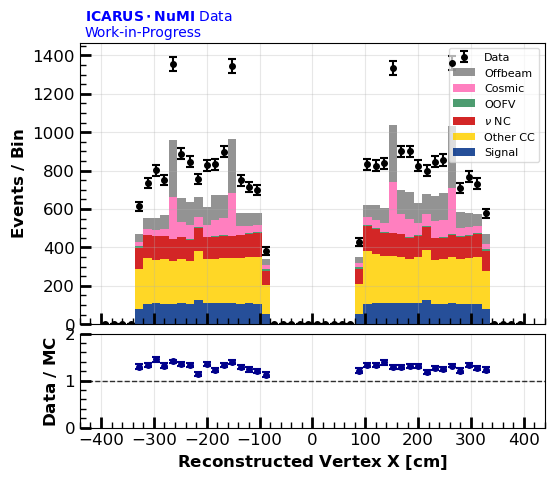

Saved: preselection_vertex_x.pdf


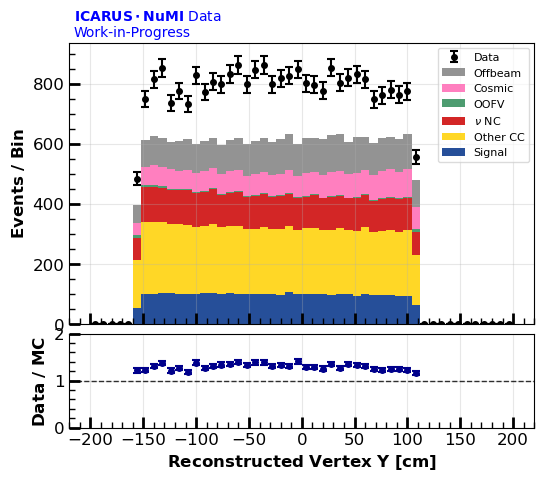

Saved: preselection_vertex_y.pdf


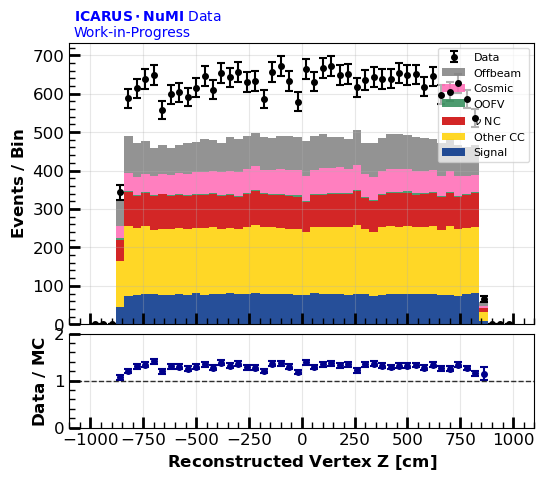

Saved: preselection_vertex_z.pdf


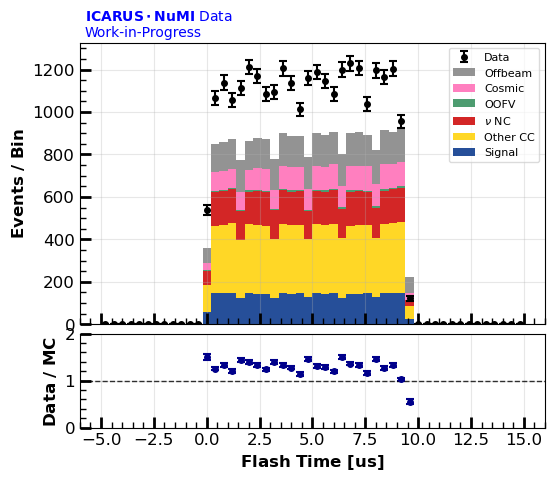

Saved: preselection_flash_time.pdf


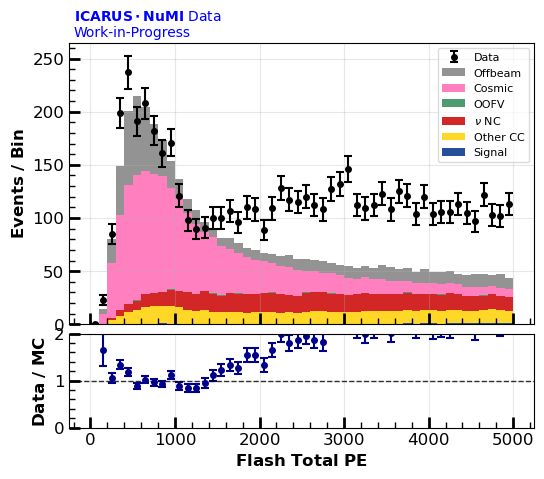

Saved: preselection_flash_total_pe.pdf


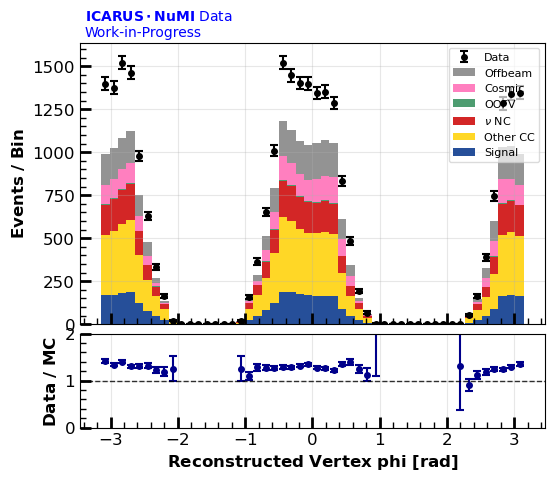

Saved: preselection_vertex_phi.pdf
Done.


In [17]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# Configuration
# ============================================================
DATA_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained.root"

OUTPUT_DIR = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/preselection"

ONBEAM_POT_OVERRIDE = 2.36124e19

# Merged Signal + Signal QE into one category
CATEGORY_MAP = {
    (0, 1, 3, 4): ("Signal",    "#003087"),
    (6, 7, 8):    ("Other CC",  "#FFD100"),
    (9,):         ("$\\nu$ NC", "#CC0000"),
    (2, 5):       ("OOFV",      "#2E8B57"),
    (10,):        ("Cosmic",    "#FF69B4"),
}

# ============================================================
# Style helpers
# ============================================================
def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=12, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', size=4, width=1, direction='in')
    ax.tick_params(axis='x', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

def add_icarus_labels(ax, data=True):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey = yrange[1] + 0.01 * (yrange[1] - yrange[0])
    usex = xrange[0] + 0.01 * (xrange[1] - xrange[0])
    label = r'$\bf{ICARUS \cdot NuMI}$ ' + ('Data' if data else 'Simulation')
    ax.text(usex, usey,
            label + '\n' + 'Work-in-Progress',
            fontsize=10, color="blue",
            verticalalignment="bottom", fontfamily="sans-serif")

# ============================================================
# Load data
# ============================================================
f = uproot.open(DATA_FILE)

nominal_pot   = f["events/nominal/POT"].values().sum()
onbeam_pot    = ONBEAM_POT_OVERRIDE
onbeam_lt     = f["events/onbeam/Livetime"].values().sum()
offbeam_lt    = f["events/offbeam/Livetime"].values().sum()

mc_scale      = onbeam_pot / nominal_pot
offbeam_scale = onbeam_lt / offbeam_lt

print(f"MC scale:      {mc_scale:.4e}")
print(f"Offbeam scale: {offbeam_scale:.4e}")

mc      = f["events/nominal/preselection"].arrays(library="pd")
onbeam  = f["events/onbeam/preselection"].arrays(library="pd")
offbeam = f["events/offbeam/preselection"].arrays(library="pd")

# Compute vertex phi
mc["reco_vertex_phi"]      = np.arctan2(mc["reco_vertex_y"],      mc["reco_vertex_x"])
onbeam["reco_vertex_phi"]  = np.arctan2(onbeam["reco_vertex_y"],  onbeam["reco_vertex_x"])
offbeam["reco_vertex_phi"] = np.arctan2(offbeam["reco_vertex_y"], offbeam["reco_vertex_x"])

def get_category_masks(df):
    masks = {}
    for cats, (label, color) in CATEGORY_MAP.items():
        mask = df["true_category"].isin(cats)
        masks[label] = (mask, color)
    return masks

mc_masks = get_category_masks(mc)

# ============================================================
# Plot function
# ============================================================
def make_plot(variable, xlabel, bins, range_, log=False, output_name=None):
    fig, (ax_main, ax_ratio) = plt.subplots(
        2, 1, figsize=(6, 5),
        gridspec_kw={"height_ratios": [3, 1]},
        sharex=True
    )
    fig.subplots_adjust(hspace=0.05)

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width   = bins[1:] - bins[:-1]

    # MC stacked histogram
    mc_total = np.zeros(len(bins) - 1)
    bottoms  = np.zeros(len(bins) - 1)

    for label, (mask, color) in mc_masks.items():
        h, _ = np.histogram(mc.loc[mask, variable].values, bins=bins, range=range_)
        h = h * mc_scale
        ax_main.bar(bin_centers, h, width=bin_width, bottom=bottoms,
                    color=color, alpha=0.85, label=label)
        bottoms  += h
        mc_total += h

    # Offbeam
    offbeam_h, _ = np.histogram(offbeam[variable].values, bins=bins, range=range_)
    offbeam_h = offbeam_h * offbeam_scale
    ax_main.bar(bin_centers, offbeam_h, width=bin_width, bottom=mc_total,
                color="grey", alpha=0.85, label="Offbeam")
    prediction = mc_total + offbeam_h

    # Data
    onbeam_h, _  = np.histogram(onbeam[variable].values, bins=bins, range=range_)
    onbeam_err   = np.sqrt(onbeam_h)
    ax_main.errorbar(bin_centers, onbeam_h, yerr=onbeam_err,
                     fmt='o', markersize=4,
                     markerfacecolor="black", markeredgecolor="black",
                     color="black", capsize=3, capthick=1.5, elinewidth=1.5,
                     label="Data", zorder=5)

    ax_main.set_ylabel(r"$\mathbf{Events\ /\ Bin}$", fontsize=12)
    if log:
        ax_main.set_yscale("log")

    ax_main.grid(True, alpha=0.3)
    apply_tick_style(ax_main)
    plt.setp(ax_main.get_xticklabels(), visible=False)

    # Legend — reversed so Data is on top
    handles, labels = ax_main.get_legend_handles_labels()
    ax_main.legend(handles[::-1], labels[::-1], fontsize=8,
                   loc="upper right", framealpha=0.7)

    # ICARUS label — upper left, above axes
    add_icarus_labels(ax_main, data=True)

    # Ratio panel
    with np.errstate(invalid="ignore", divide="ignore"):
        ratio     = np.where(prediction > 0, onbeam_h / prediction, np.nan)
        ratio_err = np.where(prediction > 0, onbeam_err / prediction, np.nan)

    ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err,
                      fmt='o', markersize=4,
                      markerfacecolor='darkblue', markeredgecolor='darkblue',
                      color='darkblue', capsize=3, capthick=1.5, elinewidth=1.5)
    ax_ratio.axhline(1.0, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
    ax_ratio.set_ylim(0.0, 2.0)
    ax_ratio.set_ylabel(r"$\mathbf{Data\ /\ MC}$", fontsize=12)
    ax_ratio.set_xlabel(r"$\mathbf{" + xlabel.replace(" ", r"\ ") + "}$", fontsize=12)
    ax_ratio.grid(True, alpha=0.3)
    apply_tick_style(ax_ratio)

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    name = output_name or variable
    fig.savefig(os.path.join(OUTPUT_DIR, f"{name}.pdf"), bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {name}.pdf")

# ============================================================
# Generate plots
# ============================================================
make_plot("reco_vertex_x",       "Reconstructed Vertex X [cm]",        np.linspace(-400, 400, 51),     (-400, 400),     output_name="preselection_vertex_x")
make_plot("reco_vertex_y",       "Reconstructed Vertex Y [cm]",         np.linspace(-200, 200, 51),     (-200, 200),     output_name="preselection_vertex_y")
make_plot("reco_vertex_z",       "Reconstructed Vertex Z [cm]",         np.linspace(-1000, 1000, 51),   (-1000, 1000),   output_name="preselection_vertex_z")
make_plot("reco_flash_time",     "Flash Time [us]",                     np.linspace(-5, 15, 51),        (-5, 15),        output_name="preselection_flash_time")
make_plot("reco_flash_total_pe", "Flash Total PE",                      np.linspace(0, 5000, 51),       (0, 5000),       output_name="preselection_flash_total_pe")
make_plot("reco_vertex_phi",     "Reconstructed Vertex phi [rad]",      np.linspace(-np.pi, np.pi, 51), (-np.pi, np.pi), output_name="preselection_vertex_phi")

print("Done.")

### Confusion Matrix

In [34]:
import uproot
import numpy as np

path = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_pid_confusion.root"

f = uproot.open(path)
tree = f["events/nominal/pid_confusion"]
print(f"Entries: {tree.num_entries}")
print(f"Branches: {tree.keys()}")

Entries: 269731
Branches: ['reco_particle_containment', 'reco_particle_electron_softmax', 'reco_particle_ke', 'reco_particle_length', 'reco_particle_muon_softmax', 'reco_particle_pdg_code', 'reco_particle_photon_softmax', 'reco_particle_pid', 'reco_particle_pion_softmax', 'reco_particle_primary_classification', 'reco_particle_proton_softmax', 'true_particle_containment', 'true_particle_ke', 'true_particle_length', 'true_particle_pdg_code', 'true_particle_pid', 'true_particle_primary_classification', 'Run', 'Subrun', 'Evt']


In [36]:
df = tree.arrays(library="pd")

print("reco_particle_pid unique:", np.unique(df["reco_particle_pid"].dropna().astype(int)))
print("true_particle_pdg_code unique:", np.unique(df["true_particle_pdg_code"].dropna().astype(int)))
print("NaN in true_pdg:", df["true_particle_pdg_code"].isna().sum())

reco_particle_pid unique: [0 1 2 3 4]
true_particle_pdg_code unique: [-321 -211  -13  -11   11   13   22  211  321 2212 3112 3222]
NaN in true_pdg: 1371


Total matched particles: 268360

Particles not in PDG map (kaons, sigmas, etc.): 108


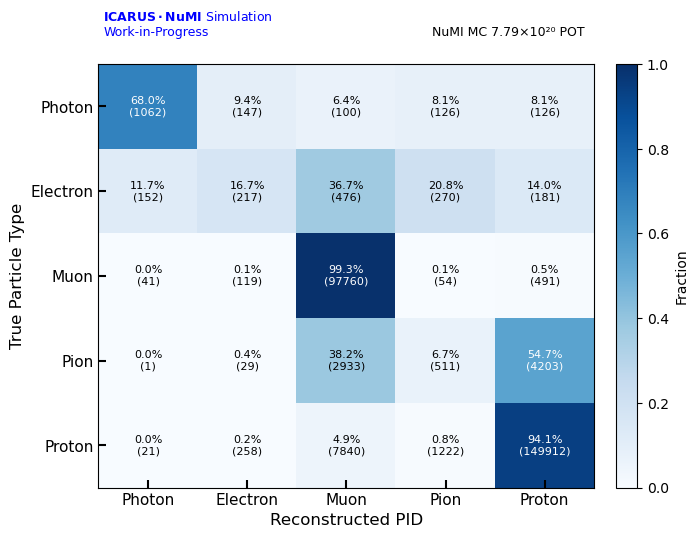

Saved: pid_confusion_matrix.pdf


In [37]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# Configuration
# ============================================================
DATA_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_pid_confusion.root"

OUTPUT_DIR = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/pid"

# SPINE PID: 0=Photon, 1=Electron, 2=Muon, 3=Pion, 4=Proton
PID_LABELS = ["Photon", "Electron", "Muon", "Pion", "Proton"]
N = 5

# Map absolute PDG to column index
# Everything not in this map goes to "Other"
PDG_TO_COL = {22: 0, 11: 1, 13: 2, 211: 3, 2212: 4}

# ============================================================
# Style helpers
# ============================================================
def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=11, size=6, width=1.5, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')

def add_icarus_label(ax):
    ax.text(0.01, 1.06,
            r'$\bf{ICARUS \cdot NuMI}$ Simulation' + '\nWork-in-Progress',
            transform=ax.transAxes, fontsize=9, color="blue",
            verticalalignment="bottom", fontfamily="sans-serif")

# ============================================================
# Load data
# ============================================================
f    = uproot.open(DATA_FILE)
tree = f["events/nominal/pid_confusion"]
df   = tree.arrays(library="pd")

# Drop unmatched particles
df = df[df["true_particle_pdg_code"].notna()].copy()
print(f"Total matched particles: {len(df)}")

# ============================================================
# Build confusion matrix
# Rows = true particle type (from true PDG)
# Cols = SPINE reco PID
# ============================================================
counts = np.zeros((N, N), dtype=float)

for _, row in df.iterrows():
    abs_pdg  = abs(int(row["true_particle_pdg_code"]))
    reco_pid = int(row["reco_particle_pid"])
    if abs_pdg in PDG_TO_COL and 0 <= reco_pid < N:
        true_idx = PDG_TO_COL[abs_pdg]
        counts[true_idx, reco_pid] += 1

# Row normalize
matrix = np.zeros_like(counts)
for i in range(N):
    row_sum = counts[i].sum()
    if row_sum > 0:
        matrix[i] = counts[i] / row_sum

print(f"\nParticles not in PDG map (kaons, sigmas, etc.): "
      f"{len(df) - int(counts.sum())}")

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=1, aspect='auto')

for i in range(N):
    for j in range(N):
        val = matrix[i, j]
        cnt = int(counts[i, j])
        if cnt == 0:
            continue
        color = "white" if val > 0.5 else "black"
        ax.text(j, i, f"{val*100:.1f}%\n({cnt})",
                ha="center", va="center", fontsize=8,
                color=color, fontfamily="sans-serif")

ax.set_xticks(range(N))
ax.set_yticks(range(N))
ax.set_xticklabels(PID_LABELS, fontsize=11)
ax.set_yticklabels(PID_LABELS, fontsize=11)
ax.set_xlabel("Reconstructed PID", fontsize=12, fontfamily="sans-serif")
ax.set_ylabel("True Particle Type", fontsize=12, fontfamily="sans-serif")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Fraction", fontsize=10)

ax.text(0.98, 1.06, "NuMI MC 7.79×10²⁰ POT",
        transform=ax.transAxes, fontsize=9,
        ha="right", va="bottom", fontfamily="sans-serif")

add_icarus_label(ax)
apply_tick_style(ax)

os.makedirs(OUTPUT_DIR, exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, "pid_confusion_matrix.pdf"), bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved: pid_confusion_matrix.pdf")